# Analiza podatkov najboljših powerlifterjev
V tem dokumentu bom predstavil podatke o najboljših powerlifterjih, ki tekmujejo brez katerih koli pripomockov (raw), ki sem jih zbral s programom *Openpowerlifting.py*.
Posebej se bom posvetil:
- analizi po disciplinah,
- dosežkom po starostnih skupinah,
- najuspešnejšim državam
- in kako so rekordi napredovali v zadnjih letih.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
osnovni_podatki = pd.read_csv("..\\Pridobitev_podatkov\\podatki.csv")

Za začetek si poglejmo najboljših 10 in njihove dosežke.

In [5]:
top10 = osnovni_podatki.sort_values("skupaj", ascending=False).head(10)
print("Najboljših 1o tekmovalcev po sestevku dvigov:")
top10[['ime','drzava', 'pocep', 'bench', 'deadlift', 'skupaj']]

Najboljših 1o tekmovalcev po sestevku dvigov:


,ime,drzava,pocep,bench,deadlift,skupaj
0,Austin Perkins #1,UK,323.0,200.0,320.0,843.0
1,Kjell Egil Bakkelund,UK,270.0,205.0,340.0,815.0
2,Elliott Sykes,Costa Rica,315.0,187.5,312.5,815.0
3,Ilya Marichev,Turkey,312.5,145.0,340.5,798.0
4,Taylor Atwood,Sweden,283.0,195.0,312.5,790.5
5,Timothy Monigatti,Lithuania,287.5,172.5,330.0,790.0
6,Carl Johansson,UK,270.0,185.0,330.5,785.5
7,Chun-Chia Fan,Germany,255.0,215.5,302.5,773.0
8,Balthazar Bertrand,Costa Rica,285.0,187.5,292.5,765.0
9,Joshua Wright #1,Lithuania,242.5,190.0,320.0,752.5


## Analiza po disciplinah
V powerliftingu se tekmuje v treh disciplinah oz. dvigih. Zanima nas, v kateri disciplini tekmovalci dvignejo največjo težo in kolikšen del njihovega seštevka predstavlja. Predvidevam, da bo večina najboljša v deadliftu in da bodo dosegli 40% svojega seštevka.

In [21]:
osnovni_podatki['max_dvig'] = osnovni_podatki[['pocep', 'bench', 'deadlift']].max(axis=1)
najboljsi_deadlift = osnovni_podatki['deadlift'] == osnovni_podatki['max_dvig']
stevilo = najboljsi_deadlift.sum()
print(f"Število tekmovalcev je {len(osnovni_podatki)}.")
print(f"Število tekmovalcev, ki imajo najbojši deadlift, je {len(najboljsi_deadlift)}.")

Število tekmovalcev je 918.
Število tekmovalcev, ki imajo najbojši deadlift, je 918.


Poglejmo, kolikšen procent njihovega seštevka deadlift predstavlja v povprečju.

In [22]:
tekmujevdeadliftu = osnovni_podatki[osnovni_podatki['deadlift'] > 0].copy() # nekateri ne tekmujejo v deadliftu in počepu ter imajo tam 0, zato bi unisčili povprečje
tekmujevdeadliftu["deadlift_%"] = tekmujevdeadliftu["deadlift"] / tekmujevdeadliftu["skupaj"]
povprecje = tekmujevdeadliftu["deadlift_%"].mean()
povprecje = povprecje * 100
print(f"V povprečju deadlift predstavlja {povprecje:.2f}% seštevka.")

V povprečju deadlift predstavlja 41.26% seštevka.


Zanima nas tudi, koliko procentov doprineseta počep in bench.

In [8]:
tekmujevdeadliftu = osnovni_podatki[osnovni_podatki['deadlift'] > 0].copy()
tekmujevdeadliftu["bench_%"] = tekmujevdeadliftu["bench"] / tekmujevdeadliftu["skupaj"]
povprecje_bench = tekmujevdeadliftu["bench_%"].mean()
povprecje_bench = povprecje_bench * 100
tekmujevdeadliftu["pocep_%"] = tekmujevdeadliftu["pocep"] / tekmujevdeadliftu["skupaj"]
povprecje_pocep = tekmujevdeadliftu["pocep_%"].mean()
povprecje_pocep = povprecje_pocep * 100
print(f"V povprečju bench predstavlja {povprecje_bench:.2f}% seštevka.")
print(f"V povprečju počep predstavlja {povprecje_pocep:.2f}% seštevka.")

V povprečju bench predstavlja 23.22% seštevka.
V povprečju počep predstavlja 35.52% seštevka.


## Dosežki po starostnih skupinah
V tem poglavju bomo pogledali, v katerih starostnih skupinah so doseženi najboljši dvigi in seštevek in ali starost sploh vpliva na največjo moč.
Najprej moramo dodati stolpec starostna skupina.


In [9]:
osnovni_podatki["starostna_skupina"] = pd.cut(
    osnovni_podatki["starost"],bins=range(16,osnovni_podatki["starost"].max() + 2, 2),
    right=False,
    labels=[f"{i}-{i + 1}" for i in range(16,osnovni_podatki["starost"].max(), 2)]
)

In [10]:
najboljsi_po_straosti = osnovni_podatki.groupby("starostna_skupina", observed=True).agg({
    "bench": "max",
    "pocep": "max",
    "deadlift": "max",
    "skupaj": "max"
}).reset_index()

nps_urejeni = najboljsi_po_straosti.sort_values(by="skupaj", ascending=False)
print(nps_urejeni.head(5))

  starostna_skupina  bench  pocep  deadlift  skupaj
4             24-25  215.5  323.0     320.0   843.0
1             18-19  187.5  315.0     312.5   815.0
3             22-23  210.5  312.5     340.5   798.0
7             30-31  195.0  283.0     312.5   790.5
5             26-27  197.5  287.5     330.0   790.0


Iz te tabele se lepo vidi, v katerih skupinah so najmočnejši posamezniki, sedaj pa si poglejmo še, kako je s povprečjem.

In [11]:
najboljsi_po_straosti_povp = osnovni_podatki.groupby("starostna_skupina", observed=True).agg({
    "bench": "mean",
    "pocep": "mean",
    "deadlift": "mean",
    "skupaj": "mean"
}).reset_index()

nps_povp_urejeni = najboljsi_po_straosti_povp.sort_values(by="skupaj", ascending=False)
pd.set_option("display.precision", 2)
print(nps_povp_urejeni.head(5))

  starostna_skupina   bench   pocep  deadlift  skupaj
4             24-25  150.94  210.11    240.00  601.05
5             26-27  150.34  205.98    237.33  593.66
7             30-31  157.50  205.14    230.36  593.00
3             22-23  147.60  185.96    211.95  545.50
1             18-19  134.62  173.97    201.09  509.68


Vidimo, da se tabela malo razlikuje, ko gre za povprečje. Narišimo še graf.

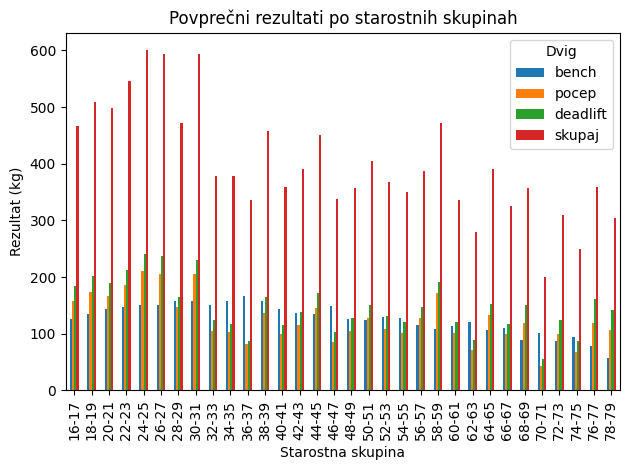

In [12]:
najboljsi_po_straosti_povp.plot(
    x="starostna_skupina",
    y=["bench", "pocep", "deadlift", "skupaj"],
    kind="bar"
    )

plt.title("Povprečni rezultati po starostnih skupinah")
plt.xlabel("Starostna skupina")
plt.ylabel("Rezultat (kg)")
plt.legend(title="Dvig")
plt.tight_layout()
plt.show()

## Uspešnost držav

Sedaj pa si poglejmo, katere države zastopajo njaboljši powerlifterji na svetu.

In [13]:
stevilo_po_drzavah = osnovni_podatki.groupby("drzava").size().reset_index(name="st_tekmovalcev")
stevilo_po_drzavah = stevilo_po_drzavah[stevilo_po_drzavah["st_tekmovalcev"] > 1]
stevilo_po_drzavah_urejeni = stevilo_po_drzavah.sort_values(by="st_tekmovalcev", ascending=False)
stevilo_po_drzavah_urejeni = stevilo_po_drzavah_urejeni.reset_index(drop=True)

print(stevilo_po_drzavah_urejeni.head(10))

         drzava  st_tekmovalcev
0        Sweden             104
1  South Africa             102
2       Finland              90
3           USA              86
4       Belarus              56
5        Canada              50
6        Norway              48
7    Costa Rica              45
8         Malta              44
9        Turkey              43


Poglejmo si, ali število tekmovalcev vpliva na uspešnost države.

In [14]:
najboljsi_total_po_drzavah = osnovni_podatki.groupby("drzava")["skupaj"].max().reset_index(name="najboljsi_skupaj")
drzave = pd.merge(stevilo_po_drzavah, najboljsi_total_po_drzavah, on="drzava")
drzave = drzave[drzave["st_tekmovalcev"] > 1]
drzave = drzave.sort_values("st_tekmovalcev", ascending=False).reset_index(drop=True)

print(drzave.head(10))

         drzava  st_tekmovalcev  najboljsi_skupaj
0        Sweden             104             790.5
1  South Africa             102             727.5
2       Finland              90             695.0
3           USA              86             730.0
4       Belarus              56             715.0
5        Canada              50             735.0
6        Norway              48             226.0
7    Costa Rica              45             815.0
8         Malta              44             745.0
9        Turkey              43             798.0


Še graf.

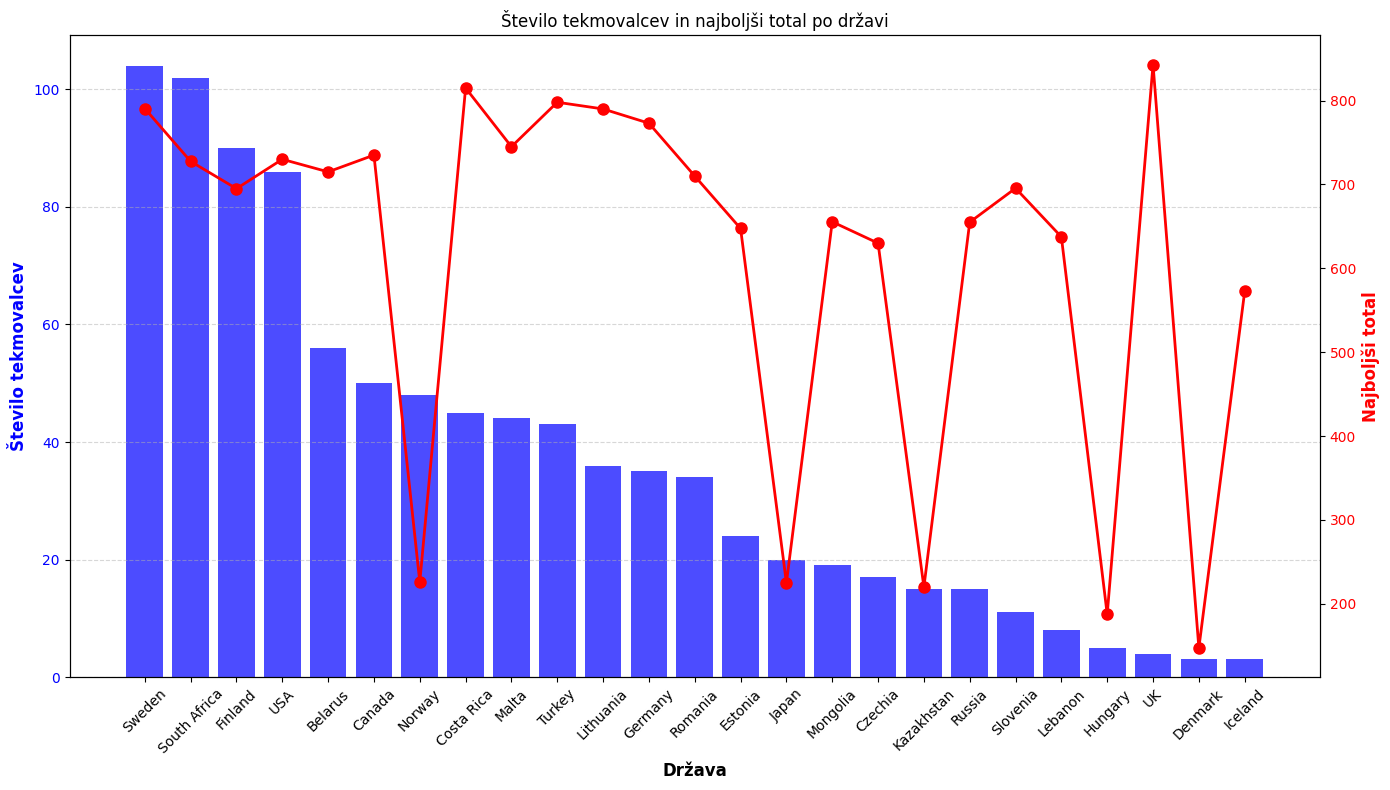

In [15]:
fig, ax1 = plt.subplots(figsize=(14,8))

color = "blue"
ax1.bar(drzave["drzava"], drzave["st_tekmovalcev"], color=color, alpha=0.7)
ax1.set_xlabel("Država", fontsize=12, fontweight='bold')
ax1.set_ylabel("Število tekmovalcev", color=color, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

color = "red"
ax2 = ax1.twinx()
ax2.plot(drzave["drzava"], drzave["najboljsi_skupaj"], color=color, marker='o', linewidth=2, markersize=8)
ax2.set_ylabel("Najboljši total", color=color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Število tekmovalcev in najboljši total po državi")
plt.tight_layout()
plt.show()

Opazimo, da ni nobenega pravila, kako število tekmovalcev vpliva na dosežke države.

## Časovni pregled rekordov
To je edino smiselno prikazati z grafom.<br>
Poglejmo si, kako so se svetovni rekordi za "raw" dvig spreminjali od leta 2012.

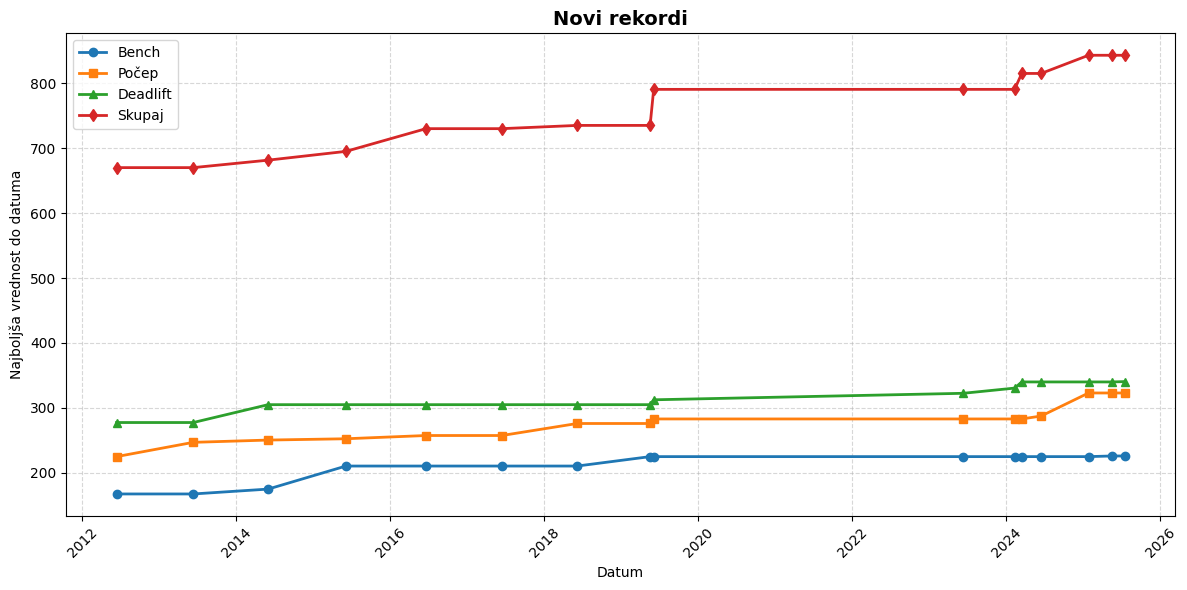

In [16]:
najboljsi_po_datumu = osnovni_podatki.groupby('datum').agg({
    'bench': 'max',
    'pocep': 'max',
    'deadlift': 'max',
    'skupaj': 'max'
}).reset_index()

najboljsi_po_datumu['datum'] = pd.to_datetime(najboljsi_po_datumu['datum'])
najboljsi_po_datumu = najboljsi_po_datumu[najboljsi_po_datumu['datum'].dt.year >= 2012]

najboljsi_po_datumu['bench_cummax'] = najboljsi_po_datumu['bench'].cummax()
najboljsi_po_datumu['pocep_cummax'] = najboljsi_po_datumu['pocep'].cummax()
najboljsi_po_datumu['deadlift_cummax'] = najboljsi_po_datumu['deadlift'].cummax()
najboljsi_po_datumu['skupaj_cummax'] = najboljsi_po_datumu['skupaj'].cummax()

novi_rekordi = najboljsi_po_datumu[
    (najboljsi_po_datumu['bench'] == najboljsi_po_datumu['bench_cummax']) |     # | pomeni OR
    (najboljsi_po_datumu['pocep'] == najboljsi_po_datumu['pocep_cummax']) |
    (najboljsi_po_datumu['deadlift'] == najboljsi_po_datumu['deadlift_cummax']) |
    (najboljsi_po_datumu['skupaj'] == najboljsi_po_datumu['skupaj_cummax'])
]

plt.figure(figsize=(12,6))
plt.plot(novi_rekordi['datum'], novi_rekordi['bench_cummax'], marker='o', label='Bench', linewidth=2)
plt.plot(novi_rekordi['datum'], novi_rekordi['pocep_cummax'], marker='s', label='Počep', linewidth=2)
plt.plot(novi_rekordi['datum'], novi_rekordi['deadlift_cummax'], marker='^', label='Deadlift', linewidth=2)
plt.plot(novi_rekordi['datum'], novi_rekordi['skupaj_cummax'], marker='d', label='Skupaj', linewidth=2)

plt.xlabel("Datum")
plt.ylabel("Najboljša vrednost do datuma")
plt.title("Novi rekordi", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()